# CROSS-VALIDATION Clustered Random Forest

In [1]:
import mod_loading as loader
from importlib import reload
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
from tqdm import tqdm


import gsw
import mod_argo
import matplotlib.pyplot as plt
from cmocean import cm as cmo

import mod_regression as mod_reg
import mod_preprocessing as mod_prep
reload(mod_reg)

<module 'mod_regression' from '/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_regression.py'>

# 1.0 Setup data

In [81]:
reload(loader)

# ==== choose data run parameters
float_carbon_var= 'pHbias5_pK1'
pcm_params='pc8_gmm6'
n_gmm = int(pcm_params.split('_')[1][-1])
desc = 'floatparam_' + float_carbon_var + '_' + pcm_params
print(desc + '; ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
# ===== import 

# Import
reload(loader)
[floatDF, shipDF] =  loader.import_preprocessed_inputs(pcm_params=pcm_params, float_param = float_carbon_var)
# [floatDF, shipDF] =  loader.import_processed_inputs(float_param = float_carbon_var)
len(floatDF), len(shipDF)


floatparam_pHbias5_pK1_pc8_gmm6; 2026-02-06 13:21:16


(11177, 6080)

In [82]:
# == IMPORT from 3.1

# folder = '../working-vars/regression/trainval-splits/'
# use_datetag = '20260206'

# trainDF = pd.read_csv('trainDF_allplat_floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4_acc'+ use_datetag + '.csv', index_col=0)
# valDF = pd.read_csv('valDF_allplat_floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4_acc'+ use_datetag + '.csv', index_col=0)




# 2.0 Subsetting training/validation using GMM probabilities

In [83]:
reload(mod_reg)
reload(loader)

# Add clustering probabilities to the float DF
# allprobs returns probabilities by profid for each class
[Y_gmm, allprobs, gmm_desc, coreDF] = loader.import_clustering_results(pcm_params = pcm_params)

finder = allprobs.set_index('profid') # temp object to search
if '0' in finder.columns:
   finder = finder.rename(columns = {str(k): k+1 for k in np.arange(n_gmm-1, -1, -1)})
# print(finder.columns)
for k in range(1, n_gmm+1):
    floatDF['class' + str(k) + '_prob'] = floatDF['profid'].apply(lambda x: finder.loc[x, k] if x in finder.index else np.nan)
    shipDF['class' + str(k) + '_prob'] = shipDF['nearest_profid'].apply(lambda x: finder.loc[x, k] if x in finder.index else np.nan)

# [Y_gmm, allprobs, gmm_desc, coreDF] = loader.import_clustering_results(pcm_params = pcm_params)

## K FOLD -

In [ ]:
# # ====== outdated K FOLD VERSION - new object CrossValContainer in mod_regression.py
# # updated feb 2026
# nfolds = 5
# platDF_all = pd.concat([floatDF, shipDF], axis=0)

# cv_container = {('fold'+str(k)): {'trainClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'valClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'trainDF_all': None,
#                                          'valDF_all':None,
#                                          'countobs':None} for k in range(1, nfolds+1)}

# for soclass in range(1, n_gmm+1):
#     # print('==> Processing class ' + str(soclass))
#     classDF = platDF_all[platDF_all['cluster'] == soclass]
#     [classDF_float, classDF_ship] = mod_reg.separate_platforms(classDF)

#     # trainfolds_float is a dictionary, keys are 'fold1' holding one class's training data
#     [trainfolds_float, valfolds_float] = mod_reg.subset_folds(classDF_float, indexer='wmoid', nfolds=nfolds)
#     [trainfolds_ship, valfolds_ship] = mod_reg.subset_folds(classDF_ship, indexer='cruiseid', nfolds=nfolds)

#     for nfold in range(1, nfolds+1):
#         # split up the data for this southern ocean class, fill in for each fold
#         foldtag = 'fold' + str(nfold)
#         foldtrain_soclass = pd.concat([trainfolds_float[foldtag], trainfolds_ship[foldtag]], axis=0)
#         foldval_soclass =  pd.concat([valfolds_float[foldtag], valfolds_ship[foldtag]], axis=0)
#         cv_container[foldtag]['trainClasses'][soclass] = foldtrain_soclass.copy() # dataframe for this class, this fold
#         cv_container[foldtag]['valClasses'][soclass] = foldval_soclass.copy()

# # After separating class data into respective folds, check train/val counts by class
# for nfold in range(1, nfolds+1):
#     foldtag = 'fold' + str(nfold)
#     cv_container[foldtag]['countobs'] = mod_reg.get_trainval_counts(cv_container[foldtag]['trainClasses'], cv_container[foldtag]['valClasses'], n_gmm=n_gmm)
#     cv_container[foldtag]['trainDF_all'] = pd.concat(cv_container[foldtag]['trainClasses'].values(), axis=0)
#     # in practice we use weighted ave so valClasses not really necessary
#     cv_container[foldtag]['valDF_all'] = pd.concat(cv_container[foldtag]['valClasses'].values(), axis=0) 

In [ ]:
# # # ====== outdated K FOLD VERSION - new object CrossValContainer in mod_regression.py
# Option to remove sea ice zone from these classes, for all folds

# cv_container_final = cv_container.copy()
# exclude_nums = [4] # gmm6=[4], gmm8=[3]

# for nfold in range(1, nfolds+1):
#     foldtag = 'fold' + str(nfold)
#     trainClasses = cv_container_final[foldtag]['trainClasses']
#     valClasses = cv_container_final[foldtag]['valClasses']
#     [cv_container_final[foldtag]['trainClasses'], 
#         cv_container_final[foldtag]['valClasses'],  
#         cv_container_final[foldtag]['trainDF_all'], 
#         cv_container_final[foldtag]['valDF_all']] = mod_reg.exclude_classes(exclude_nums, 
#                                                             trainClasses, valClasses, 
#                                                             n_gmm=n_gmm,
#                                                             reassign_numbers=True)
#     cv_container_final[foldtag]['countobs'] = mod_reg.get_trainval_counts(cv_container_final[foldtag]['trainClasses'], 
#                                                                              cv_container_final[foldtag]['valClasses'], 
#                                                                              n_gmm=n_gmm-len(exclude_nums))

[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]


In [ ]:
for nfold in range(1, nfolds+1):
    print('===> Observation counts for fold ' + str(nfold))
#     countobs = mod_reg.get_trainval_counts(cv_container_final[foldtag]['trainClasses'], folds_container[foldtag]['valClasses'], n_gmm=n_gmm-len(exclude_nums))
    print(cv_container_final[foldtag]['countobs'] )

===> Observation counts for fold 1
         train  validation  train_float  train_ship  val_float  val_ship  \
cluster                                                                    
1         2287         684          781        1506        101       583   
2         2714         521         2007         707        375       146   
3         1678         290         1408         270        211        79   
4         1596         375          744         852        141       234   
5         2179         492         1766         413        392       100   

         train_pc_float  val_pc_float  TOTAL_FLOAT  TOTAL_SHIP  TOTAL_OBS  
cluster                                                                    
1             34.149541     14.766082          882        2089       2971  
2             73.949889     71.976967         2382         853       3235  
3             83.909416     72.758621         1619         349       1968  
4             46.616541     37.600000          885  

## Trying with new object version - updated feb 6 2026

In [98]:
len(platDF_all)

17257

In [136]:
# tryig feb 6 

nfolds = 5
platDF_all = pd.concat([floatDF, shipDF], axis=0)

cvtainer = mod_reg.CrossValContainer(fold_list = ['fold' + str(k) for k in range(1, nfolds+1)], n_clusters = n_gmm)

##### 
# cvtainer = {('fold'+str(k)): {'trainClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'valClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'trainDF_all': None,
#                                          'valDF_all':None,
#                                          'countobs':None} for k in range(1, nfolds+1)}

for soclass in range(1, n_gmm+1):
    # print('==> Processing class ' + str(soclass))
    classDF = platDF_all[platDF_all['cluster'] == soclass]
    [classDF_float, classDF_ship] = mod_reg.separate_platforms(classDF)

    # trainfolds_float is a dictionary, keys are 'fold1' holding one class's training data
    [trainfolds_float, valfolds_float] = mod_reg.subset_folds(classDF_float, indexer='wmoid', nfolds=nfolds)
    [trainfolds_ship, valfolds_ship] = mod_reg.subset_folds(classDF_ship, indexer='cruiseid', nfolds=nfolds)

    for nfold in range(1, nfolds+1):
        # split up the data for this southern ocean class, fill in for each fold
        foldtag = 'fold' + str(nfold)
        foldtrain_soclass = pd.concat([trainfolds_float[foldtag], trainfolds_ship[foldtag]], axis=0)
        foldval_soclass =  pd.concat([valfolds_float[foldtag], valfolds_ship[foldtag]], axis=0)


        cvtainer.trainClasses[foldtag][soclass] =  foldtrain_soclass.copy()
        cvtainer.valClasses[foldtag][soclass] =  foldval_soclass.copy()

# After separating class data into respective folds, check train/val counts by class
for nfold in range(1, nfolds+1):
    foldtag = 'fold' + str(nfold)
    
    cvtainer.countobs[foldtag] = mod_reg.get_trainval_counts(cvtainer.trainClasses[foldtag], cvtainer.valClasses[foldtag], n_gmm=n_gmm)
    cvtainer.trainDF_all[foldtag] = pd.concat(cvtainer.trainClasses[foldtag].values(), axis=0)
    cvtainer.valDF_all[foldtag] = pd.concat(cvtainer.valClasses[foldtag].values(), axis=0)



In [137]:
# Option to remove sea ice zone from these classes, for all folds
exclude_nums = [4] # gmm6=[4], gmm8=[3]
n_clusters = n_gmm - len(exclude_nums) 
cvtainer_final = mod_reg.CrossValContainer(fold_list = ['fold' + str(k) for k in range(1, nfolds+1)], 
                                               n_clusters = n_clusters)

for nfold in range(1, nfolds+1):
    foldtag = 'fold' + str(nfold)
    trainClasses = cvtainer.trainClasses[foldtag]
    valClasses = cvtainer.valClasses[foldtag]


    [cvtainer_final.trainClasses[foldtag], 
        cvtainer_final.valClasses[foldtag],  
        cvtainer_final.trainDF_all[foldtag], 
        cvtainer_final.valDF_all[foldtag]] = mod_reg.exclude_classes(exclude_nums, 
                                                            trainClasses, valClasses, 
                                                            n_gmm=n_gmm,
                                                            reassign_numbers=True)
    cvtainer_final.countobs[foldtag] = mod_reg.get_trainval_counts(cvtainer_final.trainClasses[foldtag], 
                                                                             cvtainer_final.valClasses[foldtag], 
                                                                             n_gmm=n_clusters)




In [138]:

for fold in cvtainer_final.fold_list:
    vdat_combined = cvtainer_final.valDF_all[fold] 
    [vdat_float, vdat_ship] = mod_reg.separate_platforms(vdat_combined)
    cvtainer_final.valClasses_float[fold] = {int(ncluster):df for ncluster, df in vdat_float.groupby('cluster')}
    cvtainer_final.valClasses_ship[fold] = {int(ncluster):df for ncluster, df in vdat_ship.groupby('cluster')}

    tdat_combined = cvtainer_final.trainDF_all[fold] 
    [tdat_float, tdat_ship] = mod_reg.separate_platforms(tdat_combined)
    cvtainer_final.trainClasses_float[fold] = {int(ncluster):df for ncluster, df in tdat_float.groupby('cluster')}
    cvtainer_final.trainClasses_ship[fold] = {int(ncluster):df for ncluster, df in tdat_ship.groupby('cluster')}


In [144]:
# ======= Adjust description and ds
desc = 'floatparam_' + float_carbon_var + '_' + pcm_params

if len(exclude_nums) > 0:
    desc = desc + '_excludeClass' + str(exclude_nums[0])
    print('New description tag with excluded class: ' + desc)


New description tag with excluded class: floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4


# Plots

In [66]:
datatype_colors = {'train' : "#332288", 
                   'validation' :  "#ED7F1E", 
                   'combined' : "#524F4F",
                   'train_comb':  "#332288", 
                   'val_comb':  "#6EC3EE", 
                   'train_float': "#882255",  # rose
                   'val_float': "#DDCC77",  # rose
                   'train_ship': "#44AA99",  # dark blue
                   'val_ship': "#CC6677",  # dark blue
                   }

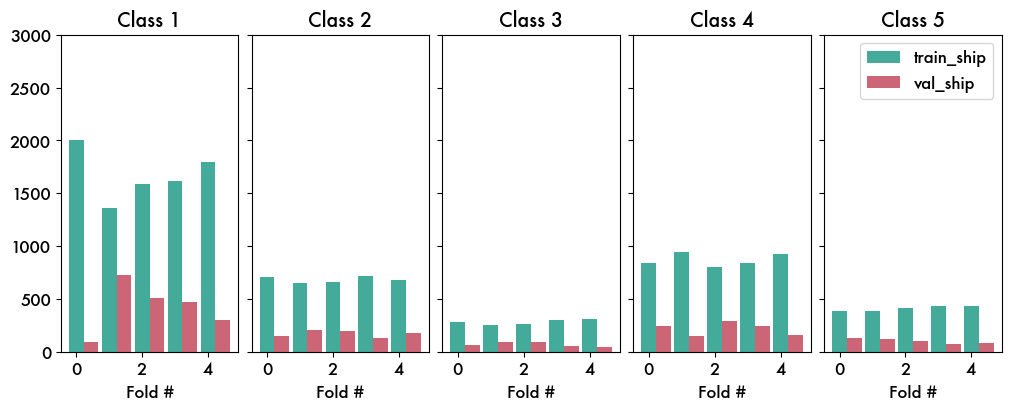

In [142]:
# VISUALIZE TRAIN/VAL COUNTS BY FOLD, BY CLASS
# === choose which data to restrict to 
# plat_type = 'comb' 
# plat_type = '_float'
plat_type = '_ship'


trainvar = 'train'; valvar = 'validation'
if plat_type in ['_float', '_ship']:
    trainvar += plat_type; valvar = valvar[:3] + plat_type

n_clusters = n_gmm - len(exclude_nums)
list_folds = ['fold'+str(k) for k in range(1, nfolds+1)]

fig, axs = plt.subplots(1, n_clusters, figsize=(2*n_clusters, 4), sharey='row', layout='constrained')

for ncluster in range(1,n_clusters+1):
    plot_data = {
        trainvar: [cvtainer_final.countobs[ftag].loc[ncluster, trainvar] for ftag in list_folds],
        valvar: [cvtainer_final.countobs[ftag].loc[ncluster, valvar] for ftag in list_folds],
    }

    x = np.arange(len(list_folds))  # the label locations
    width = 0.45  # the width of the bars
    multiplier = 0

    # fig, ax = plt.subplots(layout='constrained')

    ax = axs[ncluster-1]

    for subset_type, nobs in plot_data.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, nobs, width, label=subset_type, color=datatype_colors[subset_type])
        # ax.bar_label(rects, padding=3)
        multiplier += 1

    # ax.set_xticks(x + width, list_folds)
    ax.set_xlabel('Fold #')
    ax.set_title('Class ' + str(ncluster))

for ax in axs.flatten():
    ax.set_ylim(0,3000)
    # ax.legend(loc='upper left', ncols=3)

ax.legend()

In [ ]:
import figs_pcm

# Train RFR

In [151]:
cvtainer_final.valDF_all

{'fold1':              profid      wmoid      prof_datetag  cluster  \
 2842  5904675_id021  5904675.0  5904675_20160807        1   
 2843  5904675_id022  5904675.0  5904675_20160817        1   
 2844  5904675_id023  5904675.0  5904675_20160827        1   
 2845  5904675_id024  5904675.0  5904675_20160907        1   
 2846  5904675_id025  5904675.0  5904675_20160917        1   
 ...             ...        ...               ...      ...   
 6015            NaN        NaN               NaN        5   
 6016            NaN        NaN               NaN        5   
 6017            NaN        NaN               NaN        5   
 6077            NaN        NaN               NaN        5   
 6078            NaN        NaN               NaN        5   
 
                         datetime  latitude  longitude  linear_time     ydcos  \
 2842  2016-08-07 05:21:59.999995 -41.37900    95.8690   949.223611 -0.813307   
 2843  2016-08-17 13:21:59.999998 -41.28200    95.4760   959.556944 -0.697609   
 2

In [ ]:
# =========  Updated Jan 2026 run parameters ========= 
# Set run parameters and feature lists
reload(mod_reg)
print(desc)
feat_lists = [['CT', 'SA', 'mld'], #log(MLD) taken within the fit_single_RFR function
            ['CT', 'SA', 'mld', 'ydcos', 'ydsin'],
            ['CT', 'SA', 'mld', 'adt'],
            ['CT', 'SA', 'mld', 'adt', 'ydcos', 'ydsin'],
            ['CT', 'SA', 'mld', 'sla'],
            ['CT', 'SA', 'mld', 'sla', 'ydcos', 'ydsin'],
            # ['CT', 'SA', 'mld', 'adt', 'sla'],
            # ['CT', 'SA', 'mld', 'adt', 'sla', 'ydcos', 'ydsin']
            ]
feat_options = mod_reg.make_feat_dict(feat_lists)

# Choose trained on ship, float, or combined
# Always validate on same set of samples
# consistent_valDF = pd.concat(cvtainer_final.valDF_all.values(), axis=0) # full length of training
data_options = {'float': [cvtainer_final.trainClasses_float, cvtainer_final.valDF_all], #validationClasses
                'ship': [cvtainer_final.trainClasses_ship, cvtainer_final.valDF_all],
                'combined': [cvtainer_final.trainClasses, cvtainer_final.valDF_all]}

# Regression target variables
target_options = ['delta_pco2'] #, 'pco2']

# =========== Automatically generate run tag combinations
run_tags = mod_reg.make_run_tags(feat_options, data_options, target_options)

# ========= Set up hyperparameters ========= 
ntrees = 1000
max_feats = 1/3
min_samples_split = 5

floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4


In [ ]:
# Initiailize object
# COMMENT OUT IF YOU WANT TO KEEP OLD RUNS
# storedCV = {run_tag:{nfold:None for nfold in cvtainer_final.fold_list} for run_tag in run_tags}

In [172]:
print('===> Training RFR (' + desc + ') ' +datetime.now().strftime('%Y-%m-%d %H:%M:%S') )

for run_tag in tqdm(run_tags[:]):
    feat_key = run_tag.split('-')[0]
    dataset_key = run_tag.split('-')[1]
    var_predict = run_tag.split('-')[2]

    valdict_byFold = data_options[dataset_key][1].copy() # holds dfs
    traindict_byFold = data_options[dataset_key][0] # holds dicts

    # move here to below into mod_reg
    nclusters = n_gmm - len(exclude_nums)
    k_list = range(1,nclusters+1) # Number of clusters
    feat_list = feat_options[feat_key]

    # === TRAINING
    for nfold in cvtainer_final.fold_list:    # separate for each fold, same run tag
        RFR_clustered = mod_reg.ClusteredModelVersion(ind_list = k_list, feat_list = feat_list) #singleRun

        fold_traindict_byClass = traindict_byFold[nfold] # dictionary with keys 1...nclusters, each is a dataframe for that class, that fold
        fold_trainDF = pd.concat(fold_traindict_byClass.values())
        fold_valDF = valdict_byFold[nfold] 

        for k in k_list: 
            trainingDF_class = fold_traindict_byClass[k] # for kfold, 
            RFR_clustered.models[k] = mod_reg.fit_single_RFR(feat_list, 
                                    trainingDF_class, 
                                    var_predict = var_predict, 
                                    loss_criterion = 'squared_error',
                                    ntrees = ntrees, max_feats = max_feats,
                                    min_samples_split=min_samples_split)

        # === VALIDATION ERRORS (and training errors for calibration)
        
        RFR_clustered.weighted_training = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_trainDF, data_tag='train')
        RFR_clustered.weighted_validation = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_valDF, data_tag='val')

        storedCV[run_tag][nfold] = RFR_clustered

===> Training RFR (floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4) 2026-02-06 15:50:50


100%|██████████| 3/3 [01:35<00:00, 31.84s/it]


In [ ]:
#  ==========  Collapse errors across folds so you can treat as storedRuns for comparison and visualization functions

storedCV_collapsed = {run_tag: None for run_tag in run_tags}
k_list = range(1, n_clusters+1) # Number of clusters

for run_tag in run_tags[:]:
    # make temp obj so you can run mod_Reg functions on it like a normal ClusteredModelVersion object, 
    # collapse across folds
    tempRun = mod_reg.ClusteredModelVersion(ind_list = k_list)
    singleRun_errors_across_folds = pd.DataFrame()

    for nfold in cvtainer_final.fold_list:
        tempDF = storedCV[run_tag][nfold].weighted_validation
        tempDF['fold'] = np.tile(nfold, len(tempDF))
        singleRun_errors_across_folds = pd.concat([singleRun_errors_across_folds, tempDF], axis=0)

    # storedCV_collapsed[run_tag] = singleRun_errors_across_folds
    tempRun.weighted_validation = singleRun_errors_across_folds
    storedCV_collapsed[run_tag] = tempRun

# ========== Collapse errors into lists for each runtag to compare and plot 
runtag_errors = {rt:[mod_reg.summarize_DF_errors(storedCV[rt][use_fold].weighted_validation)[0] 
                     for use_fold in cvtainer_final.fold_list] 
                     for rt in run_tags}

In [184]:
# ==== Compare performance across different clustered-rfr runs
reload(mod_reg)
print(desc)

# storedRuns_summary = mod_reg.storedRuns_comparison(storedRuns_gmm8_ex3_MAE) # exclude class 4
use_fold = 'fold2'
storedCV_onefold = {run_tag:storedCV[run_tag][use_fold] for run_tag in run_tags}
storedRuns_summary = mod_reg.storedRuns_comparison(storedCV_onefold, run_tags[:]) # exclude class 4

# Choose which type of run to show
# show_rows = [x for x in run_tags if 'combined' in x]
show_rows = storedRuns_summary.index.tolist()

# Choose order
storedRuns_summary.loc[show_rows]
storedRuns_summary.loc[show_rows].sort_values('median_AE')

floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4


,median_AE,mean_AE,bias,RMSE
featF-ship-delta_pco2,9.734139,14.864739,-1.586192,23.342787
featD-ship-delta_pco2,9.999349,14.882510,-1.375085,22.972000
featC-ship-delta_pco2,10.070980,15.173178,-1.594220,23.326145
featB-ship-delta_pco2,10.099906,15.007943,-1.686927,23.333567
featE-ship-delta_pco2,10.101566,15.305476,-2.229233,23.732647
featA-ship-delta_pco2,10.144133,15.470474,-2.125264,24.008196
featD-combined-delta_pco2,10.544468,14.730445,2.217700,22.065251
featB-combined-delta_pco2,10.786621,14.862084,1.743085,22.410188
featF-combined-delta_pco2,10.954485,15.000441,1.853751,22.521069
featC-combined-delta_pco2,11.082756,15.115256,2.080554,22.608493


In [ ]:
storedRuns_summary.reset_index()


,index,median_AE,mean_AE,bias,RMSE
0,featA-float-delta_pco2,13.346217,16.846147,4.256056,23.873591
1,featA-ship-delta_pco2,10.144133,15.470474,-2.125264,24.008196
2,featA-combined-delta_pco2,11.949340,15.810590,1.972031,23.238843
3,featB-float-delta_pco2,12.261156,15.852311,3.656950,23.004538
4,featB-ship-delta_pco2,10.099906,15.007943,-1.686927,23.333567
5,featB-combined-delta_pco2,10.786621,14.862084,1.743085,22.410188
6,featC-float-delta_pco2,12.964335,16.675192,5.356029,23.774105
7,featC-ship-delta_pco2,10.070980,15.173178,-1.594220,23.326145
8,featC-combined-delta_pco2,11.082756,15.115256,2.080554,22.608493
9,featD-float-delta_pco2,12.464869,16.253736,5.041831,23.156702


In [206]:
runtag_errors = {rt:[mod_reg.summarize_DF_errors(storedCV[rt][use_fold].weighted_validation)[0] 
                     for use_fold in cvtainer_final.fold_list] 
                     for rt in run_tags}

/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_83706/436660679.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(run_tags, rotation=45, ha='right')


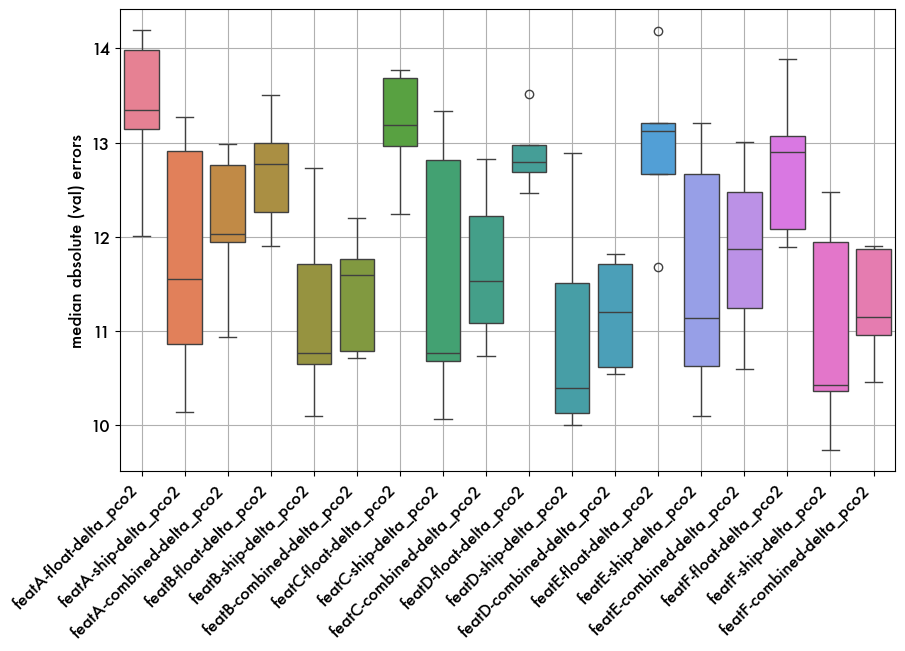

In [212]:
import seaborn as sns 
fig = plt.figure(figsize=(10,6))
ax = fig.gca()
sns.boxplot(data=runtag_errors, ax=ax)
ax.set_xticklabels(run_tags, rotation=45, ha='right')
ax.set_ylabel('median absolute (val) errors' )
ax.grid()

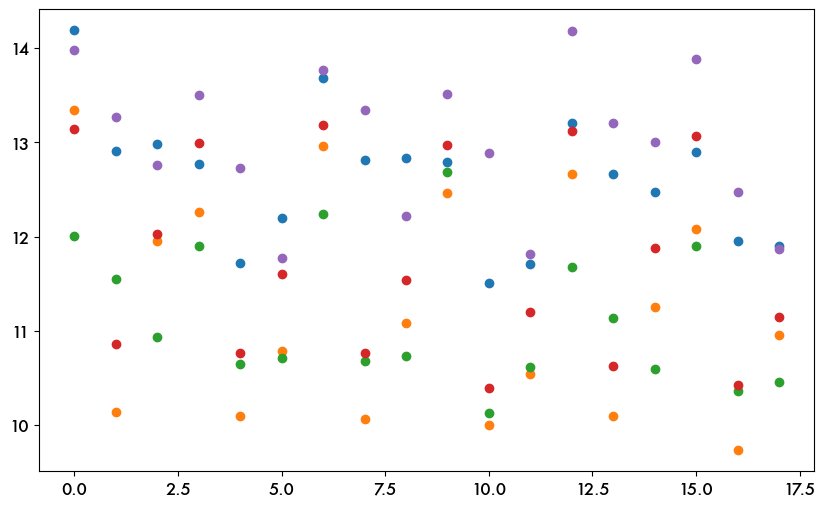

In [188]:
fig = plt.figure(figsize=(10,6))
ax = fig.gca()

use_fold = 'fold2'
for use_fold in cvtainer_final.fold_list:
    storedCV_onefold = {run_tag:storedCV[run_tag][use_fold] for run_tag in run_tags}
    storedRuns_summary = mod_reg.storedRuns_comparison(storedCV_onefold, run_tags[:]).reset_index() 

    ax.scatter(storedRuns_summary.index, storedRuns_summary.median_AE, label=use_fold)




In [ ]:
# ==== Compare performance across different clustered-rfr runs
reload(mod_reg)
print(desc)

# storedRuns_summary = mod_reg.storedRuns_comparison(storedRuns_gmm8_ex3_MAE) # exclude class 4
storedRuns_summary = mod_reg.storedRuns_comparison(storedCV_collapsed, run_tags[:]) # exclude class 4

# Choose which type of run to show
# show_rows = [x for x in run_tags if 'combined' in x]
show_rows = storedRuns_summary.index.tolist()

# Choose order
storedRuns_summary.loc[show_rows]
storedRuns_summary.loc[show_rows].sort_values('median_AE')

gmm7, excluding SIZ


,median_AE,mean_AE,bias,RMSE
featA-ship-delta_pco2,11.702885,15.996253,-3.413855,22.314195
featA-combined-delta_pco2,11.988701,16.104176,0.406863,22.260302
featA-float-delta_pco2,13.223829,17.021920,2.925278,23.063253


# Fit calibration for each class using OOF errors

In [ ]:
storedCV_collapsed # collapsed across folds 

{'featA-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0x9bb43ed00>,
 'featA-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x36c1cbfd0>,
 'featA-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0x7a7c396a0>,
 'featB-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0xa94214fd0>,
 'featB-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x7a797fa00>,
 'featB-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0xa0ff266a0>,
 'featC-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0x33dc90490>,
 'featC-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x3296207c0>,
 'featC-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0x32b590610>,
 'featD-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0x32704d160>,
 'featD-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x3637e7d90>,
 'featD-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0x326a5dd00>,
 'featE-

In [ ]:
# ========== Collapse errors into lists for each runtag to compare and plot 
runtag_errors = {rt:[mod_reg.summarize_DF_errors(storedCV[rt][use_fold].weighted_validation)[0] 
                     for use_fold in cvtainer_final.fold_list] 
                     for rt in run_tags}

In [223]:
import figs_regression as figs_reg

/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_83706/3886177691.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  singleModel_valDF['n_decile'] = pd.qcut(singleModel_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_83706/3886177691.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cal_pred = singleModel_valDF.groupby('n_decile')['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_83706/3886177691.py:7: FutureWarning:

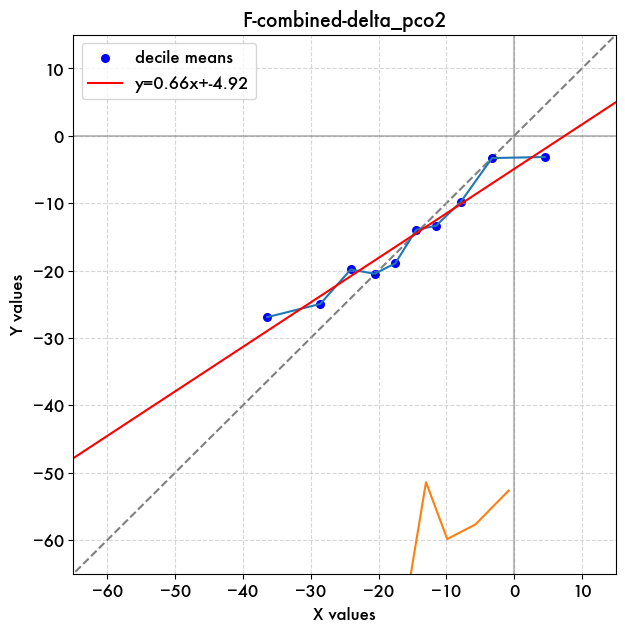

In [ ]:
# calibration plot using all folds val errors. do for each run tag 
singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation
singleModel_valDF = singleModel_valDF[singleModel_valDF.cluster==5]

singleModel_valDF['n_decile'] = pd.qcut(singleModel_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
cal_pred = singleModel_valDF.groupby('n_decile')['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
cal_obs = singleModel_valDF.groupby('n_decile')['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

stat_var = 'mean'
# === plot 
fig = plt.figure(figsize=(7,7))
ax = fig.gca()

figs_reg.plot_decile_calibration(ax, cal_pred, cal_obs, run_tag)
# figs_reg.plot_decile_calibration(ax, singleModel_valDF, run_tag)

from scipy import stats

lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

# Create the scatter plot
plt.plot(cal_pred, cal_obs)


# Plot the fitted line using plt.axline
plt.axline(xy1=(0, lincal.intercept), slope=lincal.slope, color='r', 
           label=f'y={lincal.slope:.2f}x+{lincal.intercept:.2f}')

# Add labels, a legend, and show the plot
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()




# ax.scatter(singleModel_valDF.lincal_pred, singleModel_valDF.delta_pco2, label='recalibrated', s=5, alpha=0.2, color='r')
# lincal2 = stats.linregress(singleModel_valDF.lincal_pred.values, singleModel_valDF.delta_pco2.values)
# # Plot the fitted line using plt.axline
# ax.axline(xy1=(0, lincal2.intercept), slope=lincal2.slope, color='k', 
#            label=f'y={lincal2.slope:.2f}x+{lincal2.intercept:.2f}', linestyle='-', linewidth=12, zorder=10)
plt.show()

In [315]:
calcorrections

{1: [-3.3633495608219874, 0.9488317632233807],
 2: [-1.3655454387309494, 0.9207152232533948],
 3: [-13.683158984970914, 0.49991961773371546],
 4: [-1.7418124121533012, 0.962123242169694],
 5: [-4.917045219285754, 0.6603832153207686]}

In [ ]:
def singleRun_linear_calibration(singleModel_valDF):
    # singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation

array([-52.58290717, -40.89798985, -34.9817234 , -29.60249642,
       -24.67097504, -20.10983582, -15.60256341, -11.02931539,
        -5.83957331,   2.95467519])

In [316]:


# ============== Train class dependent calibration 

# singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation


# calerror_dict = {ncluster:df for ncluster, df in singleModel_valDF.groupby('cluster')}
# calcorrections = {ncluster:None for ncluster in singleModel_valDF['cluster'].unique()}

# for ncluster, class_valDF in singleModel_valDF.groupby('cluster'):

#     class_valDF['n_decile'] = pd.qcut(class_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
#     cal_pred = class_valDF.groupby('n_decile', observed=True)['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
#     cal_obs = class_valDF.groupby('n_decile', observed=True)['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

#     stat_var = 'mean'
#     lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

#     calcorrections[ncluster] = [lincal.intercept, lincal.slope]

# APPLY CLASS DEPENDENT CORRECTION (to collapsed folds. expand by class)

for run_tag in run_tags:
    singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation
    calerror_dict = {ncluster:df for ncluster, df in singleModel_valDF.groupby('cluster')}

    # For that run, fit the linear regression for each class, store the correction factors
    calcorrections = {ncluster:None for ncluster in singleModel_valDF['cluster'].unique()}

    for ncluster, class_valDF in singleModel_valDF.groupby('cluster'):
        class_valDF['n_decile'] = pd.qcut(class_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
        cal_pred = class_valDF.groupby('n_decile', observed=True)['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
        cal_obs = class_valDF.groupby('n_decile', observed=True)['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

        stat_var = 'mean'
        lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

        calcorrections[ncluster] = [lincal.intercept, lincal.slope]

    # Apply to each class
    for ncluster in range(1, n_clusters+1):
        class_valDF = calerror_dict[ncluster].copy()
        intercept, slope = calcorrections[ncluster]

        # Apply the linear correction to the weighted_pred column
        class_valDF['lincal_pred'] = class_valDF['weighted_pred'] * slope + intercept
        calerror_dict[ncluster] = class_valDF.copy()
    
    storedCV_collapsed[run_tag].weighted_validation = pd.concat(calerror_dict.values(), axis=0)

In [317]:
mod_reg.storedRuns_comparison(storedCV_collapsed, run_tags[:], param='weighted_pred').sort_values('median_AE')

,median_AE,mean_AE,bias,RMSE
featD-ship-delta_pco2,10.763025,15.144085,-2.036941,21.350088
featF-ship-delta_pco2,10.836938,15.232629,-2.620449,21.569194
featB-ship-delta_pco2,10.993690,15.358190,-2.457953,21.637177
featD-combined-delta_pco2,11.090892,15.171021,0.699807,21.208841
featF-combined-delta_pco2,11.208018,15.295587,0.538093,21.466214
featB-combined-delta_pco2,11.328847,15.328263,0.561105,21.403396
featC-ship-delta_pco2,11.345613,15.753197,-2.699054,21.951770
featC-combined-delta_pco2,11.482746,15.763324,0.377379,21.835800
featE-ship-delta_pco2,11.487090,15.881167,-3.636663,22.134561
featA-ship-delta_pco2,11.702885,15.996253,-3.413855,22.314195


In [314]:
feat_options

{'featA': ['CT', 'SA', 'mld'],
 'featB': ['CT', 'SA', 'mld', 'ydcos', 'ydsin'],
 'featC': ['CT', 'SA', 'mld', 'adt'],
 'featD': ['CT', 'SA', 'mld', 'adt', 'ydcos', 'ydsin'],
 'featE': ['CT', 'SA', 'mld', 'sla'],
 'featF': ['CT', 'SA', 'mld', 'sla', 'ydcos', 'ydsin']}

In [318]:
mod_reg.storedRuns_comparison(storedCV_collapsed, run_tags[:], param='lincal_pred').sort_values('median_AE')


,median_AE,mean_AE,bias,RMSE
featF-ship-delta_pco2,10.788723,15.067322,0.000421,21.282029
featD-ship-delta_pco2,10.796280,15.035344,0.000310,21.146727
featD-combined-delta_pco2,10.917138,14.988790,0.000138,20.950033
featB-ship-delta_pco2,10.994494,15.197503,-0.000131,21.357112
featF-combined-delta_pco2,11.214696,15.152640,0.000601,21.156778
featB-combined-delta_pco2,11.278578,15.237516,-0.000291,21.192966
featE-ship-delta_pco2,11.287725,15.519587,-0.000625,21.717815
featC-ship-delta_pco2,11.334121,15.511347,-0.000675,21.669979
featA-ship-delta_pco2,11.372469,15.603504,-0.000394,21.817683
featC-combined-delta_pco2,11.483975,15.560345,0.000093,21.562681


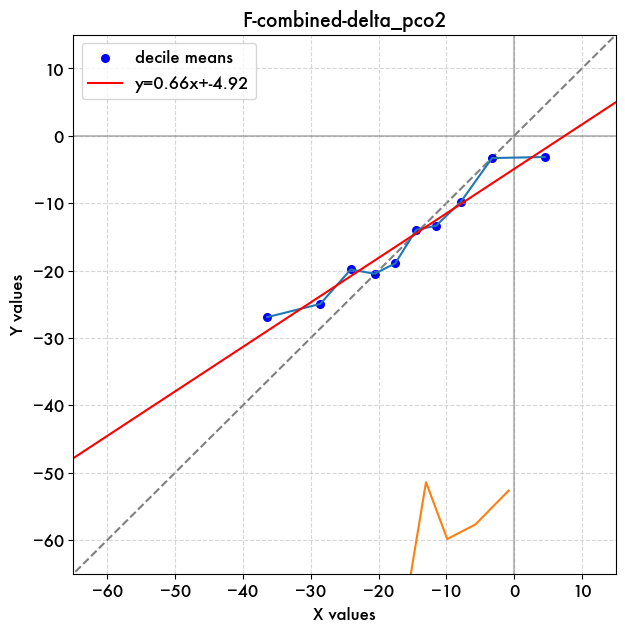

In [319]:

# === plot 
fig = plt.figure(figsize=(7,7))
ax = fig.gca()

figs_reg.plot_decile_calibration(ax, cal_pred, cal_obs, run_tag)
# figs_reg.plot_decile_calibration(ax, class_valDF, run_tag)

from scipy import stats

lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

# Create the scatter plot
plt.plot(cal_pred, cal_obs)

# Plot the fitted line using plt.axline
plt.axline(xy1=(0, lincal.intercept), slope=lincal.slope, color='r', 
           label=f'y={lincal.slope:.2f}x+{lincal.intercept:.2f}')

# Add labels, a legend, and show the plot
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.show()

In [256]:
storedCV_collapsed[run_tag].weighted_validation

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,class4_pred,class5_pred,weighted_pred,val_error,val_relative_error,fold,val_error_sq,ape,n_decile,lincal_pred
2842,5904675_id021,5904675.0,5904675_20160807,1,2016-08-07 05:21:59.999995,-41.379000,95.86900,949.223611,-0.813307,-0.581835,...,-18.329190,-33.805399,-24.507969,-13.492654,1.224899,fold1,182.051703,122.489942,5,-26.617289
2843,5904675_id022,5904675.0,5904675_20160817,1,2016-08-17 13:21:59.999998,-41.282000,95.47600,959.556944,-0.697609,-0.716479,...,-19.264839,-34.320548,-22.139719,-20.505480,12.547417,fold1,420.474720,1254.741674,6,-24.370219
2844,5904675_id023,5904675.0,5904675_20160827,1,2016-08-27 21:39:59.999998,-41.115000,95.05200,969.902778,-0.559747,-0.828663,...,-19.084029,-33.360020,-21.335254,-17.025193,3.950105,fold1,289.857205,395.010524,6,-23.606916
2845,5904675_id024,5904675.0,5904675_20160907,1,2016-09-07 05:59:00.000004,-40.963000,94.44500,980.249306,-0.404192,-0.914674,...,-21.835863,-32.126673,-15.208105,-11.564063,3.173417,fold1,133.727561,317.341704,7,-17.793283
2846,5904675_id025,5904675.0,5904675_20160917,1,2016-09-17 14:11:00.000004,-40.803000,93.75300,990.590972,-0.235948,-0.971766,...,-20.823235,-31.514912,-12.862336,-16.517481,-4.518968,fold1,272.827167,451.896816,8,-15.567543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6056,NaN,NaN,NaN,5,2022-07-26 13:17:00,-48.912000,0.11250,3128.553472,-0.916471,-0.400102,...,-10.603605,-17.150846,-3.282662,-45.066862,-1.078562,fold5,2031.022040,107.856227,9,-7.084860
6067,NaN,NaN,NaN,5,2023-01-30 12:02:01,-48.657590,102.74320,3316.501400,0.876046,0.482227,...,-16.077272,-19.447932,-19.424051,-5.140145,0.359856,fold5,26.421095,35.985573,6,-17.744363
6068,NaN,NaN,NaN,5,2023-01-31 12:13:56,-51.750025,99.28497,3317.509676,0.867551,0.497348,...,-17.046735,-13.274981,-13.313137,9.981110,-0.428480,fold5,99.622547,42.847960,8,-13.708818
6069,NaN,NaN,NaN,5,2023-02-17 12:07:05,-50.625600,102.04070,3334.504919,0.687396,0.726283,...,-14.196767,-25.641185,-25.636527,-10.048162,0.644594,fold5,100.965560,64.459369,5,-21.846978


# Fit new RF with all available data